# GP-PHS: double-well oscillator

Pipeline: **GP smoother** → **GP-PHS training** → **Hamiltonian posterior** → **trajectory**.

$$
H(\theta, p) = \frac{p^2}{2} + \frac{\theta^2}{4} + 2\cos\theta
\qquad
\dot{x} = (J-R)\nabla H
$$

| Matrix | Value |
|----------|----------|
| $J$ | $\begin{bmatrix}0 & 1 \\ -1 & 0\end{bmatrix}$ |
| $R$ | $\operatorname{diag}(0,\; b)$ with **$b$ unknown** |
| $G$ | $\begin{bmatrix}0 \\ 1\end{bmatrix}$ |


## Setup

Run the cell below once. Uses `%pip` so packages are available immediately — **no kernel restart needed**. Skips anything already installed, so re-runs are fast.

In [ ]:
%pip install gpytorch git+https://github.com/essey1/neuromancer@gp-phs -q

## Imports

In [5]:
# imports
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch
from scipy.integrate import odeint

from neuromancer.dynamics.gp_phs import PHSMatrices, GPPHSNode, GPPosterior
from neuromancer.modules.hamiltonian_approximator import HamiltonianApproximator
from neuromancer.dynamics.ode import PHSODE
from neuromancer.dataset import prepare_gpphs_data
from neuromancer.psl.gp_smoother import gp_smooth
from neuromancer.system import Node
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from torch.utils.data import DataLoader

torch.manual_seed(0); np.random.seed(0)

AttributeError: module 'sympy.core' has no attribute 'symbol'

## Configuration

In [ ]:
# config
B_TRUE   = 0.03   # true damping (model starts at 0.5)
N_POINTS = 100    # training observations
NOISE    = 0.1    # sensor noise std
N_EPOCHS = 1000
NX, NU   = 2, 1
T_SIM    = 25.0
X0_SIM   = [5, 0.0]

## True system

### Define dynamics

In [ ]:
# define system and simulate
JR_true = np.array([[0., 1.], [-1., -B_TRUE]])

def H_true(theta, p):      return 0.5*p**2 + 0.25*theta**2 + 2*np.cos(theta)
def grad_H_true(theta, p): return np.stack([0.5*theta - 2*np.sin(theta), p], axis=-1)
def dynamics(state, _):    return JR_true @ grad_H_true(state[0], state[1])

t_full    = np.linspace(0, 25.0, 1000)
traj_full = odeint(dynamics, [5.0, 0.0], t_full)
H_full    = H_true(traj_full[:, 0], traj_full[:, 1])

### Plot

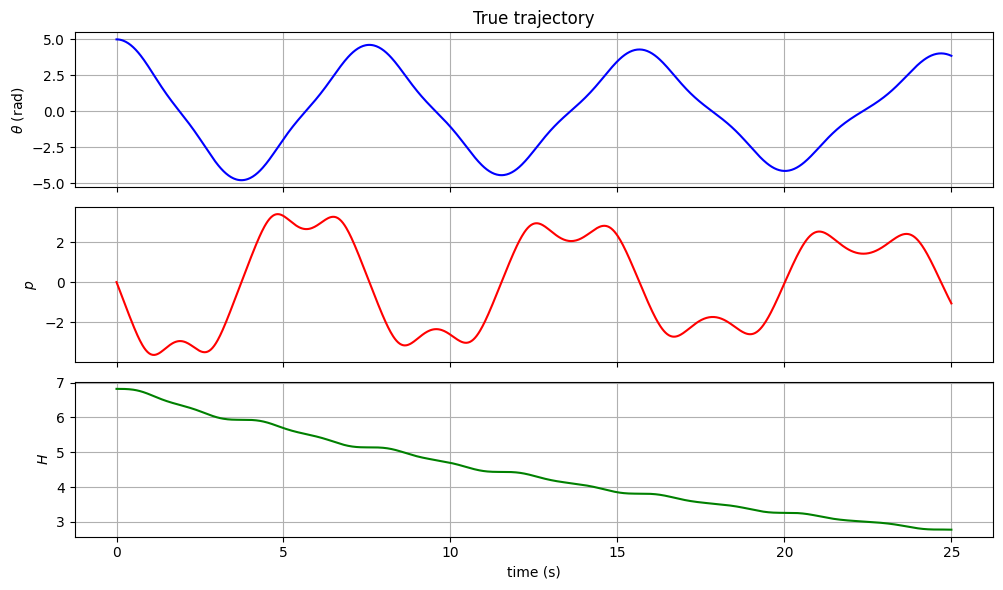

In [ ]:
# plot — states and energy
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for i, (ax, lbl, col) in enumerate(zip(axes[:2], [r'$\theta$ (rad)', '$p$'], ['b', 'r'])):
    ax.plot(t_full, traj_full[:, i], col); ax.set_ylabel(lbl); ax.grid(True)
axes[2].plot(t_full, H_full, 'g'); axes[2].set_ylabel('$H$'); axes[2].grid(True)
axes[2].set_xlabel('time (s)'); axes[0].set_title('True trajectory')
plt.tight_layout(); plt.show()

## Step 1: Noisy observations

### Sample

In [ ]:
# sample noisy observations
idx     = np.linspace(0, 999, N_POINTS, dtype=int)
t_np    = t_full[idx]
x_true  = traj_full[idx]
x_noisy = x_true + NOISE * np.random.randn(*x_true.shape)

### Plot

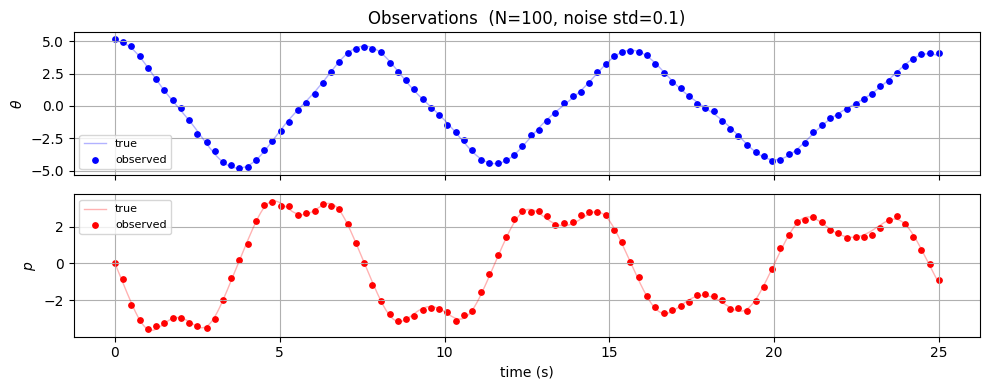

In [ ]:
# plot — noisy observations
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for i, (ax, lbl, col) in enumerate(zip(axes, [r'$\theta$', '$p$'], ['b', 'r'])):
    ax.plot(t_full, traj_full[:, i], col, lw=1, alpha=0.3, label='true')
    ax.scatter(t_np, x_noisy[:, i], c=col, s=15, label='observed')
    ax.set_ylabel(lbl); ax.legend(fontsize=8); ax.grid(True)
axes[1].set_xlabel('time (s)')
axes[0].set_title(f'Observations  (N={N_POINTS}, noise std={NOISE})')
plt.tight_layout(); plt.show()

## Step 2: GP smoother

Fits an RBF-GP to noisy states to recover smooth trajectories and derivative estimates with per-point variances.

### Smooth

In [ ]:
# smooth
x_smooth, xdot_smooth, xdot_var_np = gp_smooth(t_np, x_noisy, noise_var=NOISE**2)
gc.collect()

54385

### Plot

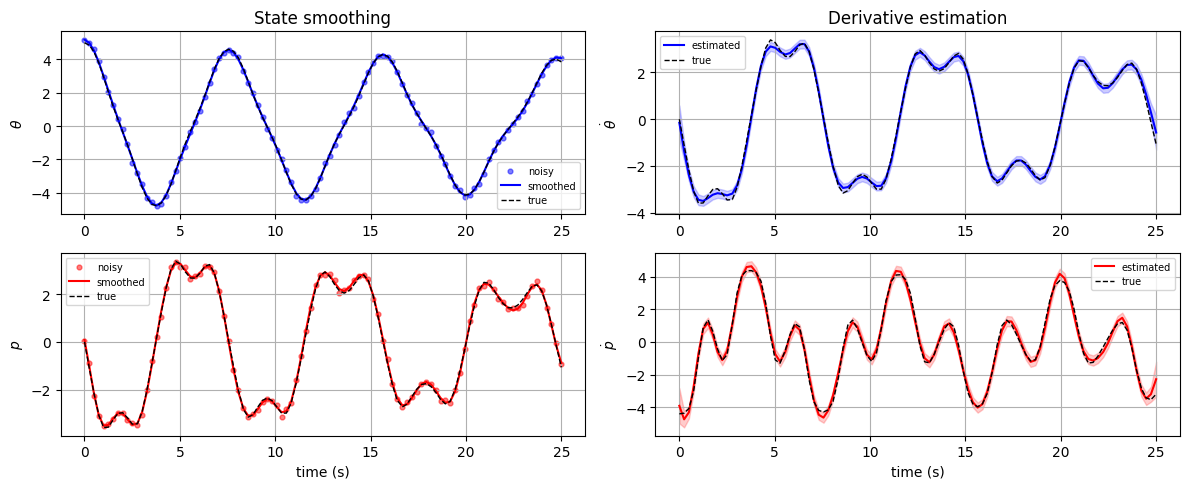

In [ ]:
# plot — smoothed states and estimated derivatives
xdot_true  = np.array([dynamics(x, 0) for x in x_true])
state_lbls = [r'$\theta$', '$p$']
deriv_lbls = [r'$\dot\theta$', r'$\dot p$']

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
for i, (lbl, dlbl, col) in enumerate(zip(state_lbls, deriv_lbls, ['b', 'r'])):
    axes[i, 0].scatter(t_np, x_noisy[:, i], c=col, s=12, alpha=0.5, label='noisy')
    axes[i, 0].plot(t_np, x_smooth[:, i], col, label='smoothed')
    axes[i, 0].plot(t_np, x_true[:, i], 'k--', lw=1, label='true')
    axes[i, 0].set_ylabel(lbl); axes[i, 0].legend(fontsize=7); axes[i, 0].grid(True)
    std = np.sqrt(xdot_var_np[:, i])
    axes[i, 1].fill_between(t_np, xdot_smooth[:, i]-2*std, xdot_smooth[:, i]+2*std, alpha=0.2, color=col)
    axes[i, 1].plot(t_np, xdot_smooth[:, i], col, label='estimated')
    axes[i, 1].plot(t_np, xdot_true[:, i], 'k--', lw=1, label='true')
    axes[i, 1].set_ylabel(dlbl); axes[i, 1].legend(fontsize=7); axes[i, 1].grid(True)
axes[0, 0].set_title('State smoothing'); axes[0, 1].set_title('Derivative estimation')
axes[1, 0].set_xlabel('time (s)'); axes[1, 1].set_xlabel('time (s)')
plt.tight_layout(); plt.show()

## Step 3: Data preparation

### Datasets and dataloaders

In [ ]:
# datasets and dataloaders
u_np = np.zeros((N_POINTS, 1))

train_ds, dev_ds, _, _ = prepare_gpphs_data(
    x_smooth, xdot_smooth, u=u_np, x_dot_var=xdot_var_np,
    split_ratio=[90.0, 10.0], batch_size=N_POINTS,
)
train_loader = DataLoader(train_ds, batch_size=N_POINTS,
                          collate_fn=train_ds.collate_fn, shuffle=False)
dev_loader   = DataLoader(dev_ds, batch_size=len(dev_ds),
                          collate_fn=dev_ds.collate_fn, shuffle=False)

## Step 4: PHS structure

Unknown damping parameterized as $b = w_b^2$ (ensures $b \geq 0$).

### Define PHS matrices

In [ ]:
# define PHS matrices
w_b = torch.nn.Parameter(torch.tensor(0.5**0.5))  # init: b = 0.5

phs = PHSMatrices(
    nx=NX, nu=NU,
    J_upper={(0, 1): lambda x: torch.ones(x.shape[0])},
    R_diag ={0:      lambda x: torch.zeros(x.shape[0]),
             1:      lambda x: w_b * torch.ones(x.shape[0])},
    G_full ={(0, 0): lambda x: torch.zeros(x.shape[0]),
             (1, 0): lambda x: torch.ones(x.shape[0])},
    extra_parameters={'w_b': w_b},
)

## Step 5: Training

Minimise NLML using the standard Neuromancer `Problem` / `Trainer` loop.

### Build node, loss, and problem

In [ ]:
# build node, loss, and problem
gpphs_module = GPPHSNode(phs, NX, NU)
gpphs_node   = Node(gpphs_module, ['X', 'U', 'Xdot', 'Xdot_var'], ['nlml'], name='gp_phs')

# symbolic variable
nlml = variable('nlml')

# objective: minimise the negative log marginal likelihood
nlml_loss      = nlml.minimize()
nlml_loss.name = 'nlml_loss'

# aggregate objectives and constraints
objectives  = [nlml_loss]
constraints = []

# loss + problem
loss    = PenaltyLoss(objectives, constraints)
problem = Problem([gpphs_node], loss)

### Train

In [ ]:
# train
optimizer = torch.optim.Adam(problem.parameters(), lr=0.1)
trainer   = Trainer(
    problem, train_loader, dev_loader,
    optimizer=optimizer,
    epochs=N_EPOCHS,
    patience=N_EPOCHS,
    epoch_verbose=100,
    train_metric='train_loss',
    dev_metric='dev_loss',
    eval_metric='dev_loss',
    clip=1.0,
)
trainer.train()

b_learned = w_b.item()**2
print(f'b learned = {b_learned:.4f}  (true = {B_TRUE})')

epoch: 0  train_loss: 1301.7447509765625
epoch: 100  train_loss: -29.306442260742188
epoch: 200  train_loss: -36.245849609375
epoch: 300  train_loss: -39.47331237792969
epoch: 400  train_loss: -41.284149169921875
b learned = 0.0405  (true = 0.03)


## Step 6: Hamiltonian posterior

$H$ is identifiable up to an additive constant; the posterior mean is aligned to the true $H$ at training points.

### Build tensors and evaluation grid

In [ ]:
# build tensors and evaluation grid
train_x    = torch.tensor(x_smooth,    dtype=torch.float32)
train_u    = torch.tensor(u_np,        dtype=torch.float32)
train_xdot = torch.tensor(xdot_smooth, dtype=torch.float32)
xdot_var_t = torch.tensor(xdot_var_np, dtype=torch.float32)

N_GRID  = 30
theta_g = np.linspace(-5, 6, N_GRID); p_g = np.linspace(-5, 5, N_GRID)
TH, P   = np.meshgrid(theta_g, p_g, indexing='ij')
x_grid  = torch.tensor(np.stack([TH.ravel(), P.ravel()], axis=1), dtype=torch.float32)
H_true_grid = H_true(TH, P)

### Compute posterior

In [ ]:
# compute posterior
kernel = gpphs_module.gp_model.covar_module
posterior = GPPosterior(
    model=gpphs_module.gp_model, likelihood=gpphs_module.likelihood,
    phs_matrices=phs, lengthscale=kernel.lengthscale.detach(),
    signal_var=kernel.signal_var.detach(), noise_var=gpphs_module.likelihood.noise.detach(),
)

H_mean_train, _, H_samples = posterior(
    train_x, train_u, train_xdot, test_x=train_x, xdot_var=xdot_var_t, n_samples=10)
H_mean_grid, _, _ = posterior(
    train_x, train_u, train_xdot, test_x=x_grid,  xdot_var=xdot_var_t, n_samples=1)

offset    = H_true(x_smooth[:, 0], x_smooth[:, 1]).mean() - H_mean_train.numpy().mean()
H_aligned = H_mean_grid.numpy().reshape(N_GRID, N_GRID) + offset

### Plot

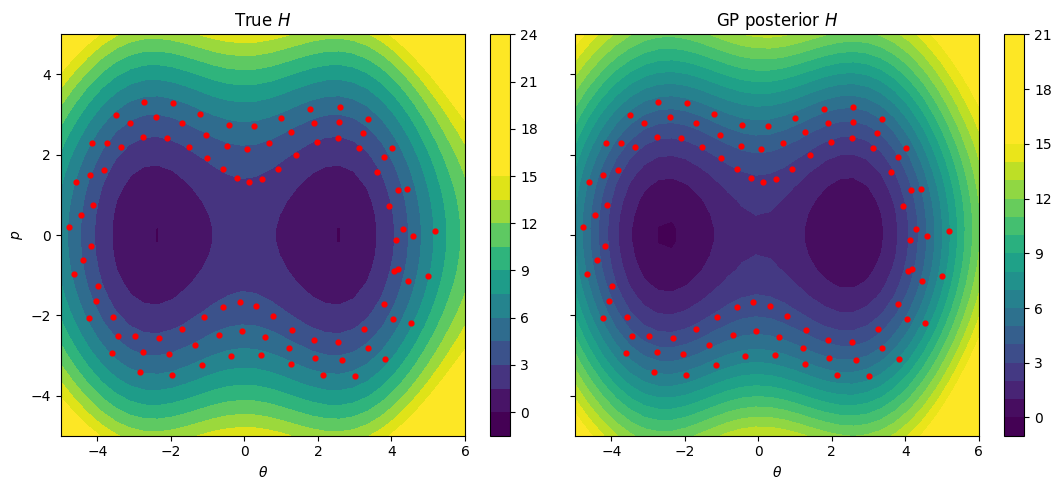

In [ ]:
# plot — Hamiltonian posterior vs true
vmin, vmax = H_true_grid.min(), min(H_true_grid.max(), 15)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, H, title in zip([ax1, ax2], [H_true_grid, H_aligned], ['True $H$', 'GP posterior $H$']):
    cf = ax.contourf(TH, P, H, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(cf, ax=ax); ax.scatter(x_smooth[:, 0], x_smooth[:, 1], c='r', s=12)
    ax.set(title=title, xlabel=r'$\theta$')
ax1.set_ylabel('$p$'); plt.tight_layout(); plt.show()

## Step 7: Callable $H^*$

Fit a GP interpolant to each posterior sample so $H^*$ can be evaluated and differentiated anywhere.

### Fit ensemble

In [ ]:
# fit ensemble of H* approximators (one per posterior sample)
n_fit   = min(N_POINTS, 200)
fit_idx = np.linspace(0, N_POINTS-1, n_fit, dtype=int)
fit_x   = train_x[fit_idx]
fit_H   = H_samples[:, fit_idx]

ensemble = [
    HamiltonianApproximator(
        method='gp',
        lengthscale=kernel.lengthscale.detach(),
        signal_var=kernel.signal_var.detach(),
    ).fit(fit_x, fit_H[i])
    for i in range(10)
]

## Step 8: Velocity field

$\dot{x} = (J(x) - R(x))\,\nabla H^*(x)$

### Compute

In [ ]:
# compute velocity field on a coarse grid
N_C = 15
theta_c = np.linspace(-5, 6, N_C); p_c = np.linspace(-5, 5, N_C)
TH_c, P_c = np.meshgrid(theta_c, p_c, indexing='ij')
x_coarse  = torch.tensor(np.stack([TH_c.ravel(), P_c.ravel()], axis=1), dtype=torch.float32)

JR_c   = (phs.get_J(x_coarse) - phs.get_R(x_coarse)).detach().numpy()
grad_c = ensemble[0].gradient(x_coarse).detach().numpy()
f_pred = np.einsum('nij,nj->ni', JR_c, grad_c)
f_true = np.array([dynamics(x_coarse[i].numpy(), 0) for i in range(len(x_coarse))])

### Plot

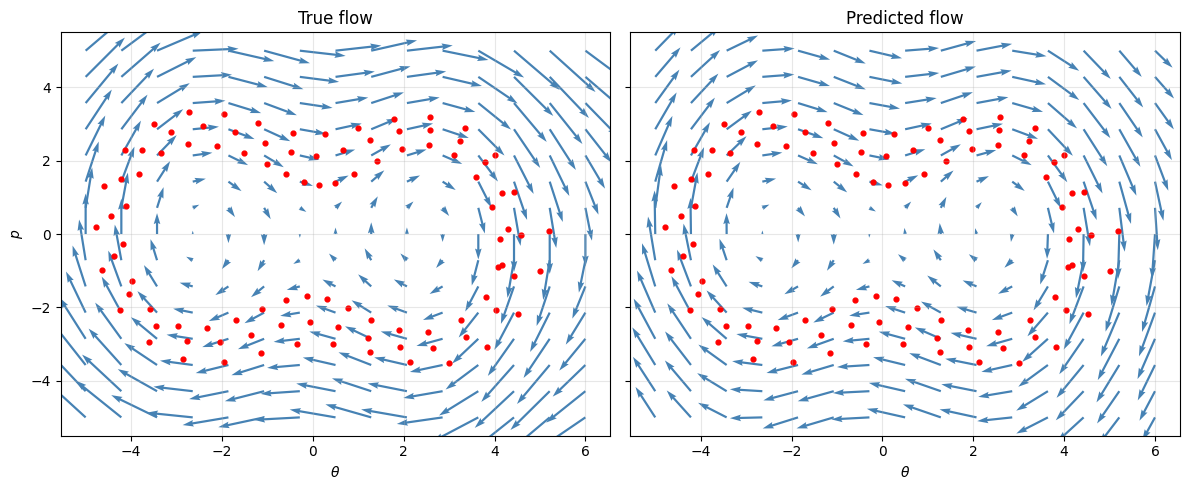

In [ ]:
# plot — velocity field (true vs predicted)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, f, title in zip([ax1, ax2], [f_true, f_pred], ['True flow', 'Predicted flow']):
    ax.quiver(TH_c, P_c, f[:, 0].reshape(N_C, N_C), f[:, 1].reshape(N_C, N_C),
              color='steelblue', scale=60)
    ax.scatter(x_smooth[:, 0], x_smooth[:, 1], c='r', s=12)
    ax.set(title=title, xlabel=r'$\theta$'); ax.grid(True, alpha=0.3)
ax1.set_ylabel('$p$'); plt.tight_layout(); plt.show()

## Step 9: Trajectory prediction

Simulate 10 trajectories (one per $H^*$ sample). Shaded band = $\pm 2$ std across the ensemble.

### Simulate

In [ ]:
# simulate
t_sim    = np.linspace(0, T_SIM, 1000)
traj_sim = odeint(dynamics, X0_SIM, t_sim)

ode = PHSODE(phs, ensemble, NX, NU, method='rk4')
with torch.no_grad():
    result = ode.simulate(
        x0=torch.tensor([X0_SIM], dtype=torch.float32),
        t_span=(0.0, T_SIM), u=torch.zeros(1, NU), dt=0.01)
t_gp = result['t_eval'].numpy()
mean = result['mean'][:, 0, :].numpy()
std  = result['std'][:, 0, :].numpy()

### Plot

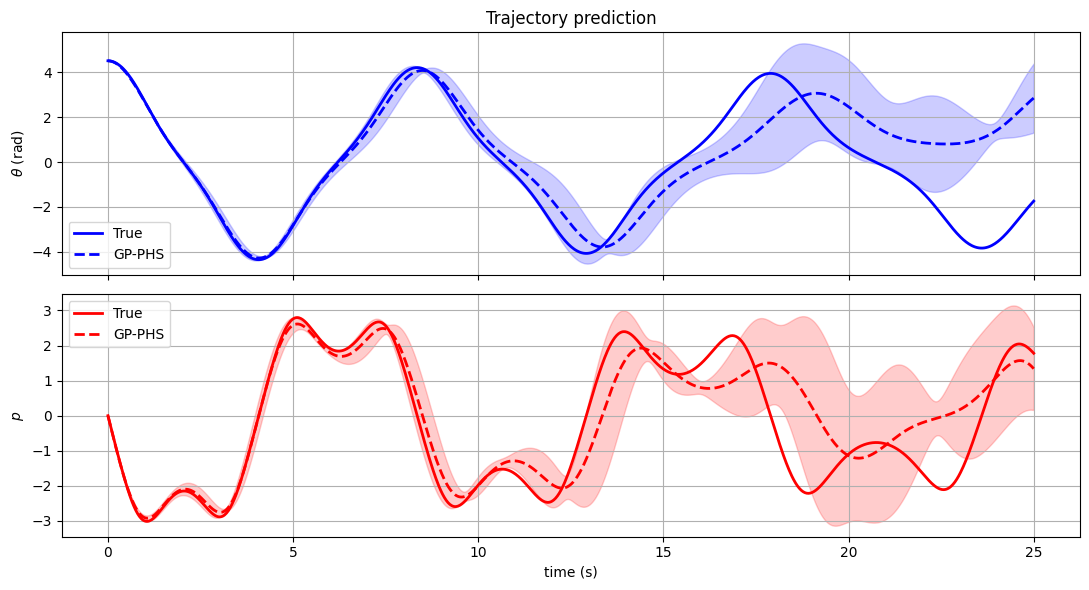

In [ ]:
# plot — trajectory prediction
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for i, (ax, lbl, col) in enumerate(zip(axes, [r'$\theta$ (rad)', '$p$'], ['b', 'r'])):
    ax.plot(t_sim, traj_sim[:, i], col, lw=2, label='True')
    ax.plot(t_gp,  mean[:, i], col+'--', lw=2, label='GP-PHS')
    ax.fill_between(t_gp, mean[:, i]-2*std[:, i], mean[:, i]+2*std[:, i],
                    alpha=0.2, color=col)
    ax.set_ylabel(lbl); ax.legend(); ax.grid(True)
axes[1].set_xlabel('time (s)'); axes[0].set_title('Trajectory prediction')
plt.tight_layout(); plt.show()